In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Titanic Survival Analysis

Exploratory analysis of the classic Titanic passenger dataset: cleaning missing values, engineering a few features from the raw columns, and checking which factors actually correlate with survival.

## Data loading & overview

In [2]:
df = pd.read_csv('titanic.csv')
avg = df['Age'].mean().round(1)
print(avg)
print(df.shape)
print(df['Survived'].value_counts())
df.head(10)

29.7
(891, 12)
Survived
0    549
1    342
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
group_ticket = df.groupby('Pclass')[['Sex','Embarked']].agg({
    "Embarked": 'count',
    'Sex': 'count'
})
print(group_ticket)
group_sex = df.groupby('Sex')[['Pclass', 'Cabin']].agg({
    'Pclass': 'count',
    'Cabin': 'count'
})
print(group_sex)


        Embarked  Sex
Pclass               
1            214  216
2            184  184
3            491  491
        Pclass  Cabin
Sex                  
female     314     97
male       577    107


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## Missing values

`Age`, `Cabin`, and `Embarked` all have gaps — checking how much of each is missing before deciding how to handle them.

In [6]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
print(df.groupby(['Pclass', 'Sex'])['Age'].median())

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64


In [8]:
# Embarked has only 2 missing values — fill with the most common port.
# Age has many more gaps (177), and age varies a lot by class and sex, so instead of one
# global median we fill each passenger's Age with the median for their own Pclass/Sex group.
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
modeE = df['Embarked'].mode()[0]
print(modeE)
df['Age'] = df['Age'].fillna(df.groupby(
        ['Pclass', 'Sex'])['Age'].transform('median')
    )

S


In [9]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,891.0,29.112424,13.304424,0.42,21.5000,26.0000,36.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


## Feature engineering

`Cabin` is missing for most passengers, but whether a passenger has a cabin recorded at all is itself informative, so that becomes a binary flag before dropping the column. We also pull a title out of each passenger's name, combine `SibSp`/`Parch` into a single family size, and encode `Sex` numerically for the correlation analysis later.

In [11]:
df.groupby(['Pclass','Sex'])['Age'].agg(['min','median','max']).round(1)

min  median   max
Pclass Sex                      
1      female  2.0    35.0  63.0
       male    0.9    40.0  80.0
2      female  2.0    28.0  57.0
       male    0.7    30.0  70.0
3      female  0.8    21.5  63.0
       male    0.4    25.0  74.0

In [12]:
print(df['Cabin'])

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: str


In [13]:
df['Has_cabin'] = df['Cabin'].notna().astype(int)
print(df['Has_cabin'].value_counts())

Has_cabin
0    687
1    204
Name: count, dtype: int64


In [14]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [15]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Has_cabin        0
dtype: int64

In [16]:
df = df.drop('Cabin', axis=1)

In [17]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_cabin      0
dtype: int64

In [18]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [19]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
print(df['Title'].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [20]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_cabin,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,Mr


In [21]:
df.insert(
    df.columns.get_loc('Parch')+1, 
    'FamilySize', 
    df['SibSp'] + df['Parch'] + 1)

In [22]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,FamilySize,Ticket,Fare,Embarked,Has_cabin,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,2,A/5 21171,7.2500,S,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,2,PC 17599,71.2833,C,1,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,1,STON/O2. 3101282,7.9250,S,0,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,2,113803,53.1000,S,1,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,1,373450,8.0500,S,0,Mr


In [23]:
df['FamilySize'].unique()

array([ 2,  1,  5,  3,  7,  6,  4,  8, 11])

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
print((df['Fare']==0).sum())

15


In [26]:
print(df[df['Fare']==0])

     PassengerId  Survived  Pclass                              Name   Sex  \
179          180         0       3               Leonard, Mr. Lionel  male   
263          264         0       1             Harrison, Mr. William  male   
271          272         1       3      Tornquist, Mr. William Henry  male   
277          278         0       2       Parkes, Mr. Francis "Frank"  male   
302          303         0       3   Johnson, Mr. William Cahoone Jr  male   
413          414         0       2    Cunningham, Mr. Alfred Fleming  male   
466          467         0       2             Campbell, Mr. William  male   
481          482         0       2  Frost, Mr. Anthony Wood "Archie"  male   
597          598         0       3               Johnson, Mr. Alfred  male   
633          634         0       1     Parr, Mr. William Henry Marsh  male   
674          675         0       2        Watson, Mr. Ennis Hastings  male   
732          733         0       2              Knight, Mr. Robe

### Why Are There Zeros Here?
After checking the names, we can assume that these people traveled for free as crew members; therefore, their cost is `0`.


In [27]:
print(df.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean').round(3))

Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   FamilySize   891 non-null    int64  
 9   Ticket       891 non-null    str    
 10  Fare         891 non-null    float64
 11  Embarked     891 non-null    str    
 12  Has_cabin    891 non-null    int64  
 13  Title        891 non-null    str    
dtypes: float64(2), int64(7), str(5)
memory usage: 97.6 KB


In [29]:
df['IsAlone'] = (df['FamilySize']==1).astype(int)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,FamilySize,Ticket,Fare,Embarked,Has_cabin,Title,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,2,A/5 21171,7.2500,S,0,Mr,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,2,PC 17599,71.2833,C,1,Mrs,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,1,STON/O2. 3101282,7.9250,S,0,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,2,113803,53.1000,S,1,Mrs,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,1,373450,8.0500,S,0,Mr,1


In [30]:
df['Sex_encoded'] = df['Sex'].map({'male':0,'female':1})
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'FamilySize', 'Ticket', 'Fare', 'Embarked', 'Has_cabin',
       'Title', 'IsAlone', 'Sex_encoded'],
      dtype='str')

<Axes: >

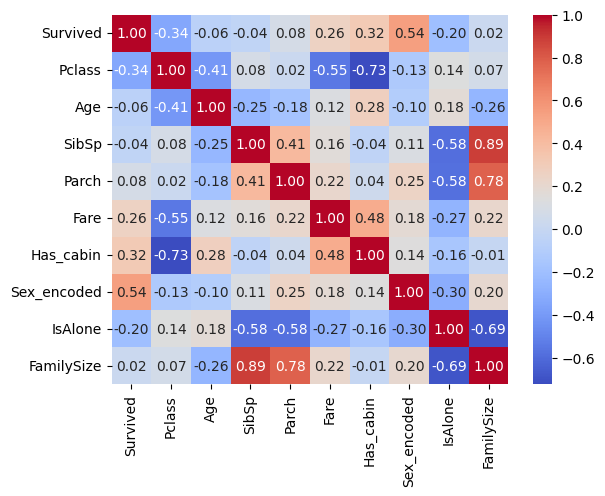

In [31]:
cols_for_corr = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Has_cabin', 'Sex_encoded','IsAlone','FamilySize']

corr_matrix = df[cols_for_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

## Exploratory analysis

Checking how survival breaks down by the engineered features and the original variables.

In [32]:
df.groupby('FamilySize')['Survived'].agg(['mean','count'])

,mean,count
FamilySize,,
1,0.303538,537
2,0.552795,161
3,0.578431,102
4,0.724138,29
5,0.200000,15
6,0.136364,22
7,0.333333,12
8,0.000000,6
11,0.000000,7


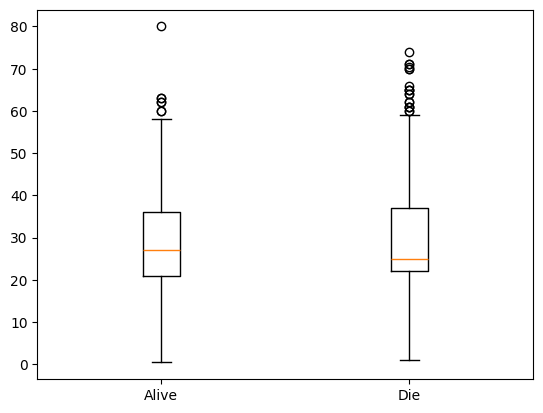

In [33]:
survived_ages = df[df['Survived']==1]['Age']
died_ages = df[df['Survived']==0]['Age']

plt.boxplot([survived_ages,died_ages], tick_labels=['Alive', 'Die'])
plt.show()

In [34]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [35]:
age_groups = pd.cut(df['Age'], bins=[0,12,18,35,60,100], labels = ['Child', 'Teen', 'Adult', 'Middle-aged', 'Elderly'])

result = df.groupby(age_groups)['Survived'].agg(['mean','count'])
result

,mean,count
Age,,
Child,0.579710,69
Teen,0.428571,70
Adult,0.357977,514
Middle-aged,0.384259,216
Elderly,0.227273,22


In [36]:
result = df.groupby([age_groups,'Sex'])['Survived'].agg(['mean','count'])
result

mean  count
Age         Sex                    
Child       female  0.593750     32
            male    0.567568     37
Teen        female  0.750000     36
            male    0.088235     34
Adult       female  0.751445    173
            male    0.158358    341
Middle-aged female  0.771429     70
            male    0.198630    146
Elderly     female  1.000000      3
            male    0.105263     19

In [37]:
print(survived_ages.var(), died_ages.var())

196.29593755980858 164.30790056240278


## Statistical tests

The boxplots and group means suggest survivors skew younger and paid higher fares — checking whether those differences are actually statistically significant (Welch's t-test, since the two groups don't have equal variance) rather than just eyeballing the charts.

In [38]:
t_stats, p_value = stats.ttest_ind(survived_ages, died_ages, equal_var=False)
print(f't-statistics: {t_stats:.3f}, p-value: {p_value:.3f}')

t-statistics: -1.743, p-value: 0.082


In [39]:
survived_fare = df[df['Survived']==1]['Fare']
died_fare = df[df['Survived']==0]['Fare']

t_stats, p_value = stats.ttest_ind(survived_fare, died_fare, equal_var=False)
print(f't-statistics: {t_stats:.3f}, p-value: {p_value:.3f}')

t-statistics: 6.839, p-value: 0.000


## Conclusions

- **Sex and class dominate survival.** Women in 1st/2nd class survived at over 90%, while men in 3rd class survived at just 13.5%.
- **Fare matters, but it's really a class proxy.** The Fare difference between survivors and non-survivors is statistically significant (t = 6.84, p < 0.001) — people who paid more tended to be in higher classes, which had better access to lifeboats.
- **Age is not a significant factor on its own** (t = -1.74, p = 0.082) once you look at the full population — children did better, but the effect isn't strong enough across all ages to call it significant at the 5% level.
- **Traveling with a small family (2-4 people) improved survival odds** compared to traveling alone or with a large family (5+) — very large families had the worst survival rate of all, likely because they were harder to keep together while evacuating.
- **Having a recorded cabin number correlates with survival**, but this is almost certainly picking up the same class effect: cabin numbers were recorded far more often for 1st class passengers.